# 📈 Evaluate All Models
Loads every saved model and generates full comparison

Run AFTER `02_training_testing.ipynb`

---
### Cells
1. Imports & Config
2. Discover Models
3. Load Test Data
4. Single Model Evaluator
5. Run All Evaluations
6. Comparison Table & Plots
7. Best Model Recommendation

## Cell 1 — Imports & Config

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import gc

DATASET_PATH = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
ORIG_PATH    = r'D:\Files\AI X-Ray Detection\Dataset'
MODELS_PATH  = r'D:\Files\AI X-Ray Detection\Models'
RESULTS_PATH = r'D:\Files\AI X-Ray Detection\Reports'
CLASSES      = ['normal', 'pneumonia', 'tuberculosis']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 16

if not os.path.exists(DATASET_PATH):
    DATASET_PATH = ORIG_PATH

print('✅ Config ready')

✅ Config ready


## Cell 2 — Discover Saved Models

In [2]:
model_files = [os.path.join(MODELS_PATH, f) for f in os.listdir(MODELS_PATH)
               if f.endswith('.keras') or f.endswith('.h5')]

if not model_files:
    print(f'❌ No models found in {MODELS_PATH}')
    print(f'   Run 02_training_testing.ipynb first')
else:
    print(f'Found {len(model_files)} model(s):')
    for mf in model_files:
        size_mb = os.path.getsize(mf) / 1e6
        print(f'  {os.path.basename(mf)} ({size_mb:.1f} MB)')

Found 2 model(s):
  EfficientNetB4_best.keras (123.7 MB)
  EfficientNetB4_finetuned.keras (163.9 MB)


## Cell 3 — Load Test Data

In [3]:
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(test_gen.class_indices.keys())
y_true      = test_gen.classes
n_classes   = len(CLASS_NAMES)
y_true_bin  = label_binarize(y_true, classes=list(range(n_classes)))

print(f'Test samples : {test_gen.samples}')
print(f'Classes      : {CLASS_NAMES}')

Found 1451 images belonging to 3 classes.
Test samples : 1451
Classes      : ['normal', 'pneumonia', 'tuberculosis']


## Cell 4 — Single Model Evaluator

In [4]:
def evaluate_single(model_path, model_name):
    print(f'\n  Evaluating: {model_name}')
    model = tf.keras.models.load_model(model_path, compile=False)

    # Inference speed
    sample = np.zeros((1,224,224,3), dtype=np.float32)
    model.predict(sample, verbose=0)
    start  = time.time()
    for _ in range(10): model.predict(sample, verbose=0)
    inf_ms = (time.time()-start)/10*1000

    test_gen.reset()
    y_pred         = model.predict(test_gen, verbose=1)
    y_pred_classes = np.argmax(y_pred, axis=1)
    overall_acc    = float(np.sum(y_pred_classes==y_true)/len(y_true))
    report_dict    = classification_report(y_true, y_pred_classes,
                        target_names=CLASS_NAMES, output_dict=True)

    auc_scores = {}
    for i, cls in enumerate(CLASS_NAMES):
        try: auc_scores[cls] = float(roc_auc_score(y_true_bin[:,i], y_pred[:,i]))
        except: auc_scores[cls] = 0.0

    result = {
        'model_name'    : model_name,
        'accuracy'      : round(overall_acc, 4),
        'macro_auc'     : round(float(np.mean(list(auc_scores.values()))), 4),
        'inference_ms'  : round(inf_ms, 2),
        'total_params'  : model.count_params(),
        'y_pred'        : y_pred,
        'y_pred_classes': y_pred_classes,
        'auc_scores'    : auc_scores,
    }
    for cls in CLASS_NAMES:
        if cls in report_dict:
            result[f'{cls}_precision'] = round(report_dict[cls]['precision'], 4)
            result[f'{cls}_recall']    = round(report_dict[cls]['recall'], 4)
            result[f'{cls}_f1']        = round(report_dict[cls]['f1-score'], 4)
            result[f'{cls}_auc']       = round(auc_scores.get(cls,0), 4)

    print(f'    Accuracy   : {overall_acc*100:.2f}%')
    print(f'    Macro AUC  : {result["macro_auc"]:.4f}')
    print(f'    Inference  : {inf_ms:.1f} ms/image')
    print(f'    Parameters : {model.count_params():,}')

    del model; gc.collect()
    return result

print('✅ Evaluator ready')

✅ Evaluator ready


## Cell 5 — Run All Evaluations

In [5]:
all_results = []
for model_path in model_files:
    model_name = Path(model_path).stem.replace('_best','')
    try:
        result = evaluate_single(model_path, model_name)
        all_results.append(result)
    except Exception as e:
        print(f'  ❌ {model_name} failed: {e}')

print(f'\n✅ Evaluated {len(all_results)} model(s)')


  Evaluating: EfficientNetB4
91/91 ━━━━━━━━━━━━━━━━━━━━ 53s 545ms/step
    Accuracy   : 84.15%
    Macro AUC  : 0.9697
    Inference  : 100.8 ms/image
    Parameters : 18,731,106

  Evaluating: EfficientNetB4_finetuned
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 541ms/step
    Accuracy   : 87.46%
    Macro AUC  : 0.9700
    Inference  : 102.9 ms/image
    Parameters : 18,731,106

✅ Evaluated 2 model(s)


## Cell 6 — Comparison Table & Plots


  MODEL COMPARISON TABLE
  Model                       Acc      AUC   ms/img    normal R    pneumo R    tuberc R
  --------------------------------------------------------------------
  🏆 EfficientNetB4_finetuned   0.8746   0.9700    102.9      0.8529      0.9722      0.8158
     EfficientNetB4         0.8415   0.9697    100.8      0.9265      0.9167      0.7072


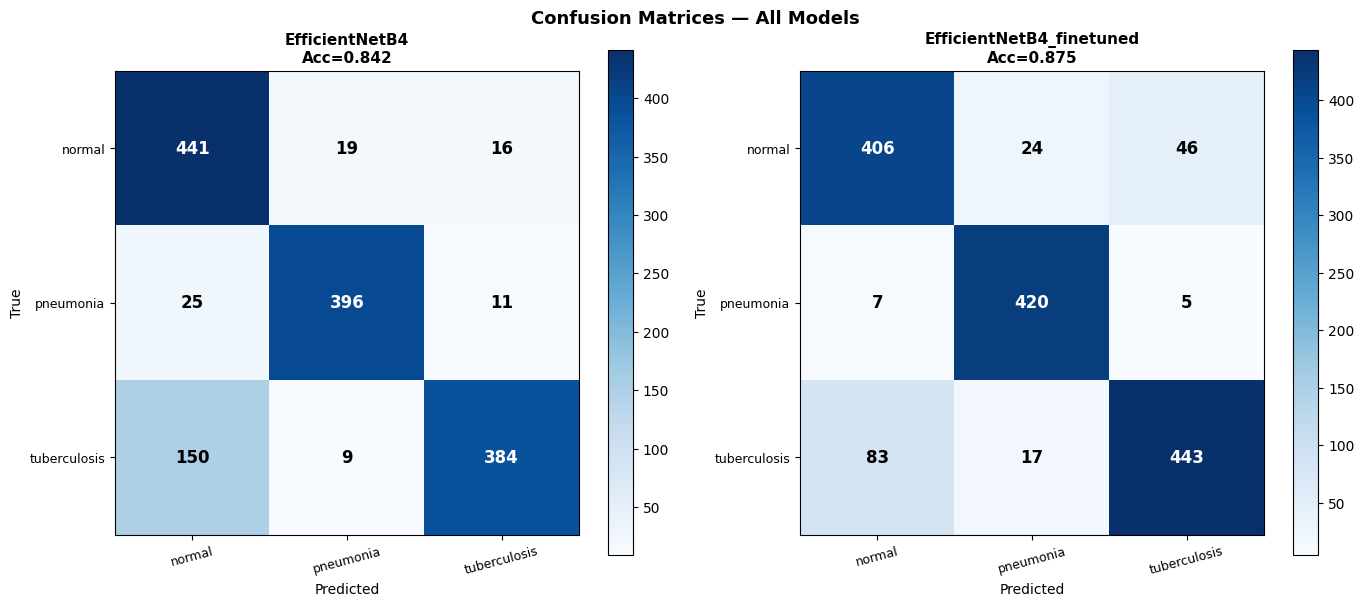

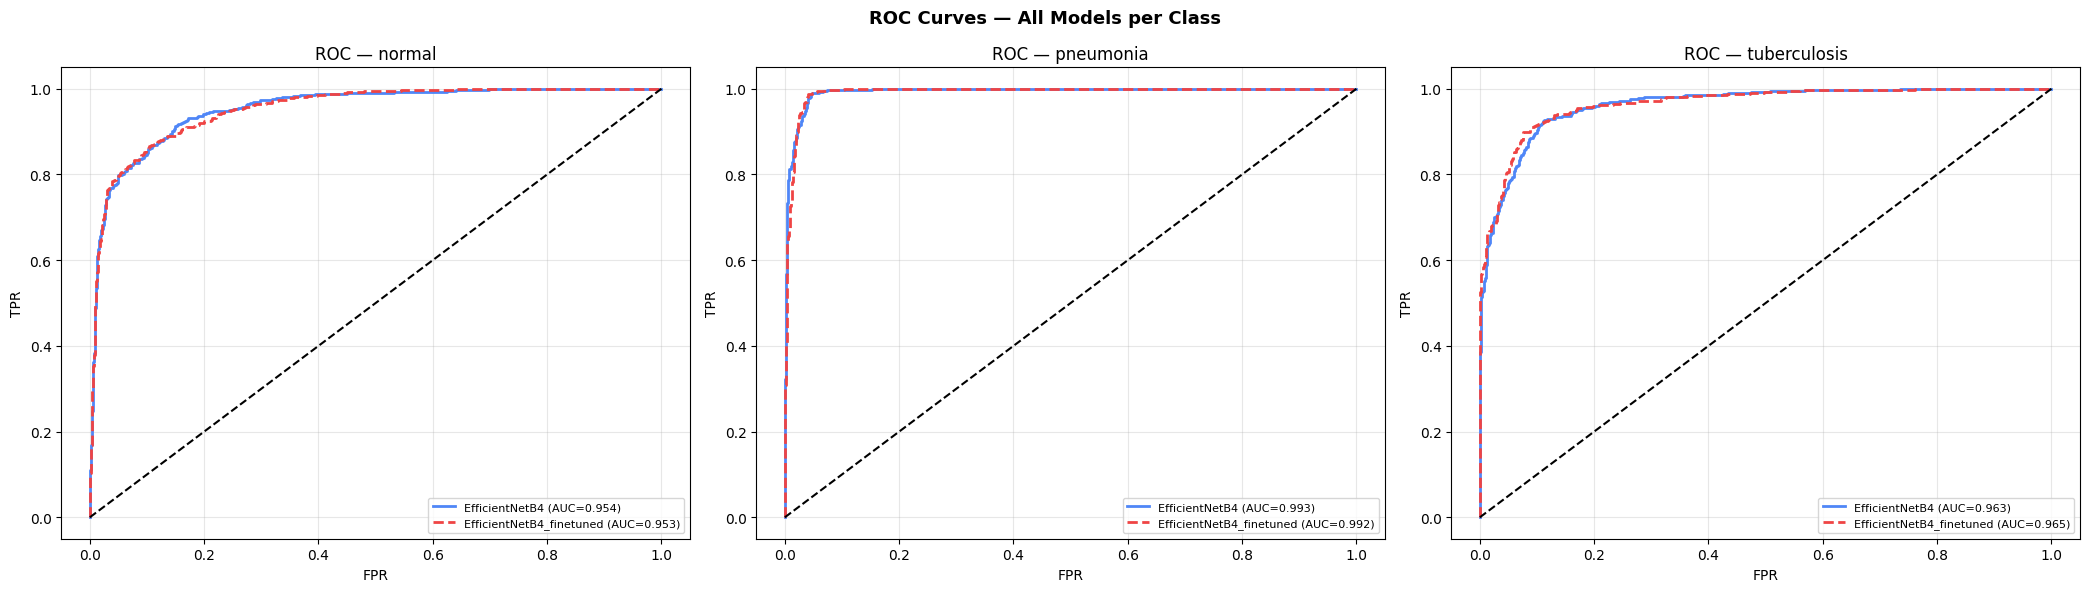

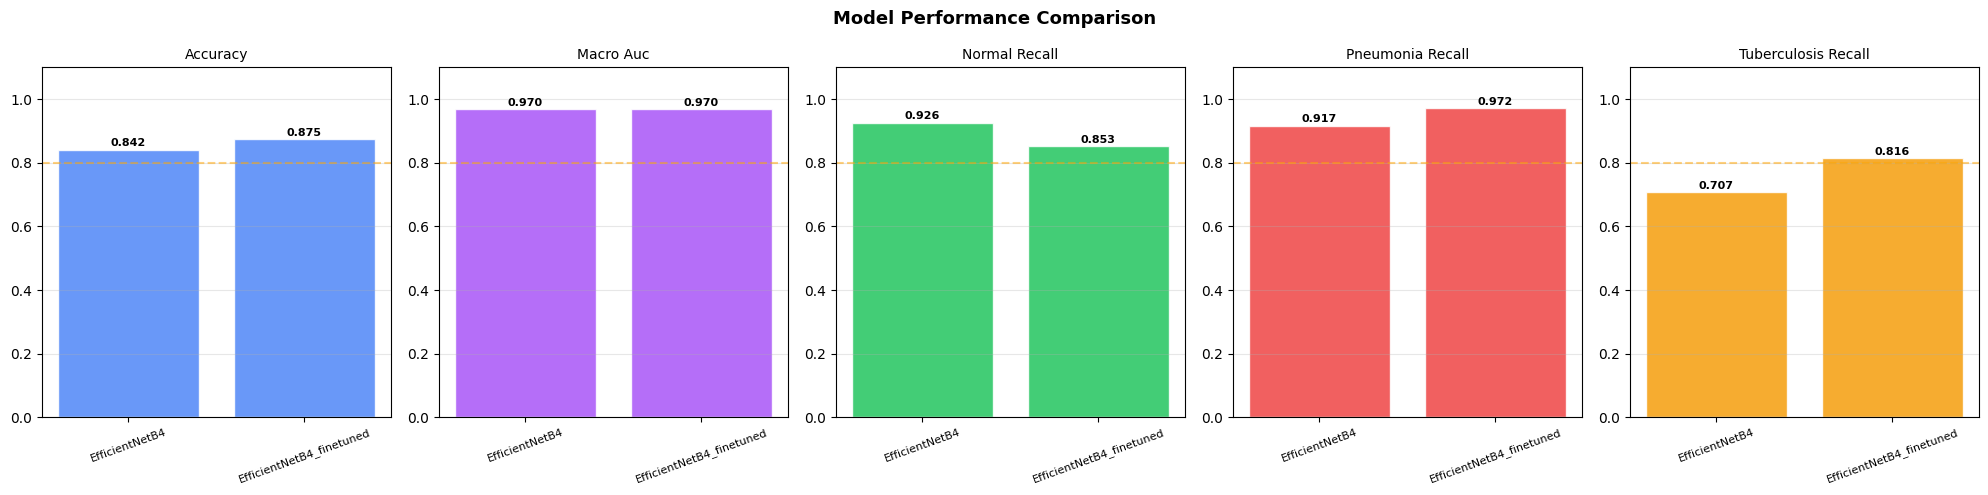


✅ All plots and CSV saved → D:\Files\AI X-Ray Detection\Reports


In [6]:
# Comparison Table
print(f'\n{"="*70}')
print('  MODEL COMPARISON TABLE')
print(f'{"="*70}')
print(f'  {"Model":<22} {"Acc":>8} {"AUC":>8} {"ms/img":>8}', end='')
for cls in CLASS_NAMES: print(f'  {(cls[:6]+" R"):>10}', end='')
print()
print(f'  {"-"*68}')
for r in sorted(all_results, key=lambda x: x['accuracy'], reverse=True):
    flag = '🏆' if r == max(all_results, key=lambda x: x['accuracy']) else '  '
    recalls = [r.get(f'{cls}_recall',0) for cls in CLASS_NAMES]
    print(f'  {flag} {r["model_name"]:<20} {r["accuracy"]:>8.4f} {r["macro_auc"]:>8.4f} '
          f'{r["inference_ms"]:>8.1f}' + ''.join(f'  {rec:>10.4f}' for rec in recalls))

# Confusion Matrices
n_m = len(all_results)
fig, axes = plt.subplots(1, n_m, figsize=(7*n_m, 6))
if n_m == 1: axes = [axes]
fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
for ax, r in zip(axes, all_results):
    cm     = confusion_matrix(y_true, r['y_pred_classes'])
    im     = ax.imshow(cm, cmap=plt.cm.Blues)
    thresh = cm.max()/2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=12,fontweight='bold',
                    color='white' if cm[i,j]>thresh else 'black')
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(CLASS_NAMES,rotation=15,fontsize=9)
    ax.set_yticklabels(CLASS_NAMES,fontsize=9)
    ax.set_title(f'{r["model_name"]}\nAcc={r["accuracy"]:.3f}',fontsize=11,fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); plt.colorbar(im,ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH,'all_models_confusion.png'), dpi=130)
plt.show()

# ROC Curves
colors_m = ['#4f86f7','#ef4444','#22c55e']
linestyles = ['-','--',':']
fig, axes = plt.subplots(1, n_classes, figsize=(7*n_classes, 6))
if n_classes == 1: axes = [axes]
fig.suptitle('ROC Curves — All Models per Class', fontsize=13, fontweight='bold')
for ax, cls_idx, cls in zip(axes, range(n_classes), CLASS_NAMES):
    for r, color, ls in zip(all_results, colors_m, linestyles):
        try:
            fpr,tpr,_ = roc_curve(y_true_bin[:,cls_idx], r['y_pred'][:,cls_idx])
            auc = r['auc_scores'].get(cls,0)
            ax.plot(fpr,tpr,color=color,linestyle=ls,linewidth=2,label=f'{r["model_name"]} (AUC={auc:.3f})')
        except: pass
    ax.plot([0,1],[0,1],'k--')
    ax.set_title(f'ROC — {cls}'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH,'all_models_roc.png'), dpi=130)
plt.show()

# Bar Comparison
metrics_to_plot = ['accuracy','macro_auc'] + [f'{cls}_recall' for cls in CLASS_NAMES]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4*len(metrics_to_plot), 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
bar_colors = ['#4f86f7','#a855f7','#22c55e','#ef4444','#f59e0b']
for ax, metric, color in zip(axes, metrics_to_plot, bar_colors):
    names = [r['model_name'] for r in all_results]
    vals  = [r.get(metric,0) for r in all_results]
    bars  = ax.bar(names, vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metric.replace('_',' ').title(), fontsize=10)
    ax.set_ylim(0,1.1); ax.tick_params(axis='x',rotation=20,labelsize=8)
    ax.axhline(y=0.8,color='orange',linestyle='--',alpha=0.5)
    ax.grid(axis='y',alpha=0.3)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH,'all_models_comparison.png'), dpi=150)
plt.show()

# Save CSV
save_cols = [k for k in all_results[0].keys() if k not in ('y_pred','y_pred_classes','auc_scores')]
pd.DataFrame([{k:r[k] for k in save_cols} for r in all_results]
    ).sort_values('accuracy',ascending=False
    ).to_csv(os.path.join(RESULTS_PATH,'all_models_comparison.csv'), index=False)
print(f'\n✅ All plots and CSV saved → {RESULTS_PATH}')

## Cell 7 — Best Model Recommendation

In [7]:
best = max(all_results, key=lambda x: x['accuracy'])
print(f'\n{"="*55}')
print(f'  🏆 BEST MODEL: {best["model_name"]}')
print(f'{"="*55}')
print(f'  Test Accuracy : {best["accuracy"]*100:.2f}%')
print(f'  Macro AUC     : {best["macro_auc"]:.4f}')
print(f'  Inference     : {best["inference_ms"]:.1f} ms/image')
print(f'  Parameters    : {best["total_params"]:,}')
print(f'\n  Per-class Recall:')
for cls in CLASS_NAMES:
    rec  = best.get(f'{cls}_recall', 0)
    flag = '✅' if rec >= 0.80 else '⚠️ '
    print(f'    {cls:<18} {rec:.4f}  {flag}')
print(f'\n  Update ml_api.py with:')
print(f'  MODEL_PATH  = r\'{os.path.join(MODELS_PATH, best["model_name"]+"_best.keras")}\'')
print(f'  CLASS_NAMES = {CLASS_NAMES}')


  🏆 BEST MODEL: EfficientNetB4_finetuned
  Test Accuracy : 87.46%
  Macro AUC     : 0.9700
  Inference     : 102.9 ms/image
  Parameters    : 18,731,106

  Per-class Recall:
    normal             0.8529  ✅
    pneumonia          0.9722  ✅
    tuberculosis       0.8158  ✅

  Update ml_api.py with:
  MODEL_PATH  = r'D:\Files\AI X-Ray Detection\Models\EfficientNetB4_finetuned_best.keras'
  CLASS_NAMES = ['normal', 'pneumonia', 'tuberculosis']
